# Customer Churn Prediction & Risk Segmentation

![alt text](Customer_Churn/Customer_churn.png)

**Importing The Libraries**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("Telco_customer_churn.xlsx")
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


**Check Top 10 Rows of the Dataset**

In [5]:
df.head(10)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
5,4190-MFLUW,1,United States,California,Los Angeles,90020,"34.066367, -118.309868",34.066367,-118.309868,Female,...,Month-to-month,No,Credit card (automatic),55.20,528.35,Yes,1,78,5925,Competitor offered higher download speeds
6,8779-QRDMV,1,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582,Male,...,Month-to-month,Yes,Electronic check,39.65,39.65,Yes,1,100,5433,Competitor offered more data
7,1066-JKSGK,1,United States,California,Los Angeles,90024,"34.066303, -118.435479",34.066303,-118.435479,Male,...,Month-to-month,No,Mailed check,20.15,20.15,Yes,1,92,4832,Competitor made better offer
8,6467-CHFZW,1,United States,California,Los Angeles,90028,"34.099869, -118.326843",34.099869,-118.326843,Male,...,Month-to-month,Yes,Electronic check,99.35,4749.15,Yes,1,77,5789,Competitor had better devices
9,8665-UTDHZ,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Month-to-month,No,Electronic check,30.20,30.2,Yes,1,97,2915,Competitor had better devices


**Check Last 10 Rows of the Dataset**

In [ ]:
df.tail(10)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
7033,0871-OPBXW,1,United States,California,Twentynine Palms,92277,"34.17211, -115.769773",34.172110,-115.769773,Female,...,Month-to-month,Yes,Mailed check,20.05,39.25,No,0,80,5191,NaN
7034,3605-JISKB,1,United States,California,Twentynine Palms,92278,"34.457829, -116.139589",34.457829,-116.139589,Male,...,One year,No,Credit card (automatic),60.00,3316.1,No,0,71,4212,NaN
7035,9767-FFLEM,1,United States,California,Westmorland,92281,"33.03679, -115.60503",33.036790,-115.605030,Male,...,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No,0,35,4591,NaN
7036,8456-QDAVC,1,United States,California,Winterhaven,92283,"32.852947, -114.850784",32.852947,-114.850784,Male,...,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.1,No,0,20,2464,NaN
7037,7750-EYXWZ,1,United States,California,Yucca Valley,92284,"34.159534, -116.425984",34.159534,-116.425984,Female,...,One year,No,Electronic check,60.65,743.3,No,0,24,3740,NaN
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN
7042,3186-AJIEK,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.424926,-117.184503,Male,...,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No,0,38,5097,NaN


**Shape of Dataset**

In [ ]:
df.shape

(7043, 33)

**Data type of each column**

In [ ]:
df.dtypes

CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges         object
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object

**Find number of rows and number of columns**

In [ ]:
print("No of Rows:",df.shape[0])
print("No of columns:",df.shape[1])

No of Rows: 7043
No of columns: 33


**Get the Information About Our Dataset Like Total Number of Rows, Total Number of Columns, Datatypes of Each Column And Memory Requirment**

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

**Check Null Values in the Dataset**

In [ ]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

**Convert TotalCharges to Numeric**

In [ ]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [8]:
df["Churn Reason"] = df["Churn Reason"].fillna(df["Churn Reason"].mode()[0])

In [ ]:
df.isnull().sum()

CustomerID            0
Count                 0
Country               0
State                 0
City                  0
Zip Code              0
Lat Long              0
Latitude              0
Longitude             0
Gender                0
Senior Citizen        0
Partner               0
Dependents            0
Tenure Months         0
Phone Service         0
Multiple Lines        0
Internet Service      0
Online Security       0
Online Backup         0
Device Protection     0
Tech Support          0
Streaming TV          0
Streaming Movies      0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
Total Charges        11
Churn Label           0
Churn Value           0
Churn Score           0
CLTV                  0
Churn Reason          0
dtype: int64

**Checking For Duplicates in the Dataset**

In [7]:
print(df.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool


**Dropping unwanted columns**

In [6]:
df.drop("CustomerID", axis=1, inplace=True)

Removed the customerID column because it is a unique identifier with no predictive value. Keeping it could introduce noise and negatively affect model performance.

**Get Overall Statistics About in the Dataset**

In [8]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


**To Separate categorical and numerical features**

In [9]:
categorical_features=df.select_dtypes(include='object').columns
numerical_features=df.select_dtypes(exclude='object').columns
print(categorical_features)
print(numerical_features)

Index(['Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Online Security', 'Online Backup',
       'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
       'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges',
       'Churn Label', 'Churn Reason'],
      dtype='str')
Index(['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months',
       'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV'],
      dtype='str')


C:\Users\jinit\AppData\Local\Temp\ipykernel_19856\4266015089.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features=df.select_dtypes(include='object').columns


# Data Visualization

* we will represent the data through use of common graphics, such as plots,charts and heatmaps. These visual graphs will allow us to get a better understanding of the dataset and find correlations between its features.

In [11]:
# 1. Set the background style
sns.set_theme(style="whitegrid", font_scale=1.1)
colors = {
    "No": "#1f77b4",
    "Yes": "#e74c3c"
}

def add_labels(ax):
    for container in ax.containers:
        ax.bar_label(container, fontsize=10, fontweight='bold', padding=3)

**Customer Churn Distribution**

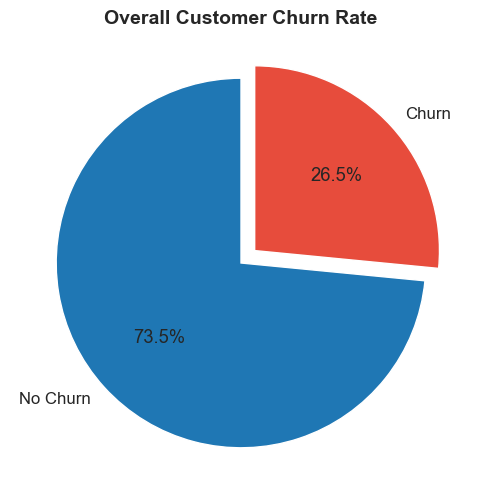

In [12]:
churn_counts = df["Churn Label"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    churn_counts,
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%",
    colors=[colors["No"], colors["Yes"]],
    startangle=90,
    explode=(0, 0.1)
)

plt.title("Overall Customer Churn Rate", fontsize=14, fontweight="bold")

plt.show()

Most customers do not churn, but a significant portion leaves the service, indicating a need for proactive retention strategies.

**Churn by Contract Type**

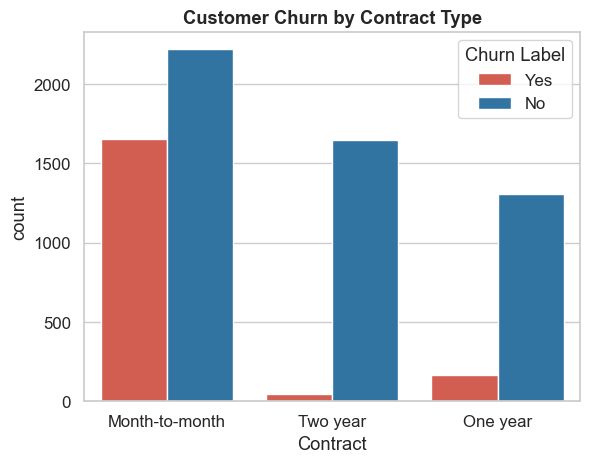

In [14]:
plt.title("Customer Churn by Contract Type", fontweight="bold")
sns.countplot(
    x="Contract",
    hue="Churn Label",
    data=df,
    palette=colors
)

plt.show()

Customers with month-to-month contracts have the highest churn rate, while long-term contracts significantly improve customer retention.

**Churn by Internet Service**

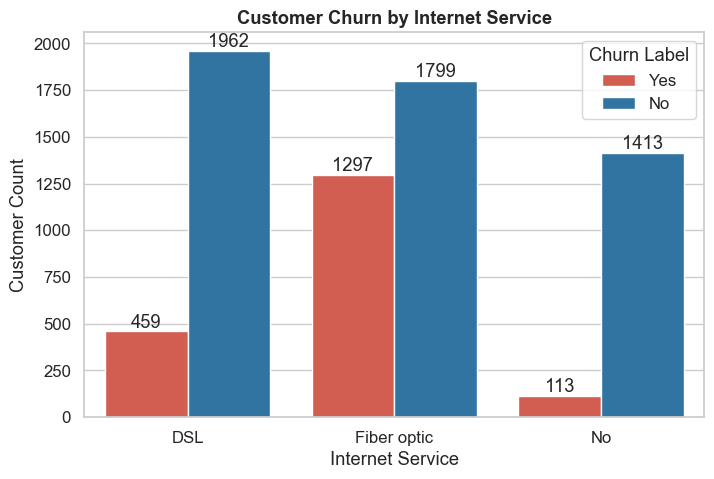

In [15]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x="Internet Service",
    hue="Churn Label",
    data=df,
     palette=colors
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Internet Service", fontweight="bold")
plt.xlabel("Internet Service")
plt.ylabel("Customer Count")

plt.legend(title="Churn Label")

plt.show()

Customers using Fiber Optic internet show higher churn compared to DSL users, possibly due to higher costs or service expectations.

**Churn By Payment Method**

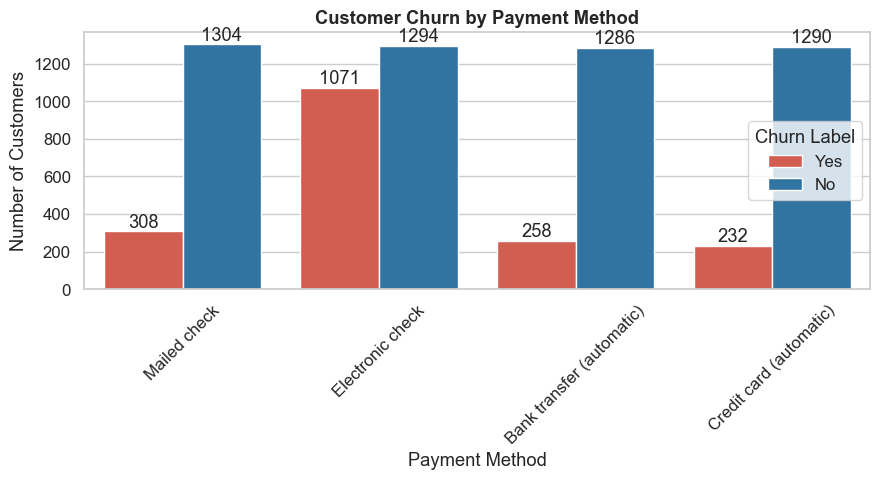

In [16]:
plt.figure(figsize=(9,5))

ax = sns.countplot(
    x="Payment Method",
    hue="Churn Label",
    data=df,
    palette=colors
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Payment Method", fontweight="bold")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.legend(title="Churn Label")

plt.tight_layout()

plt.show()

Customers using electronic check payment methods exhibit higher churn rates, indicating a potential risk segment.

**Churn by Gender**

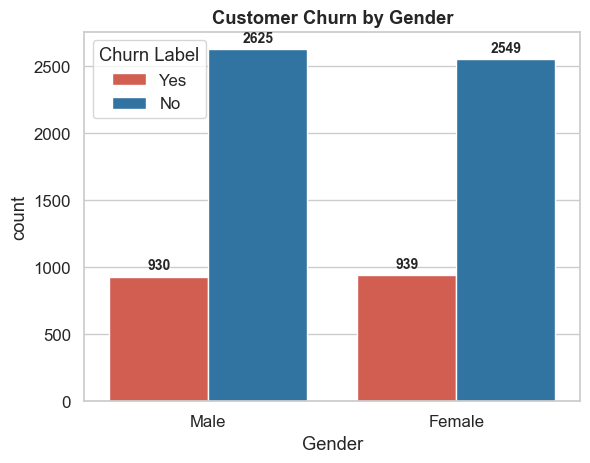

In [17]:
ax = sns.countplot(
    x="Gender",
    hue="Churn Label",
    data=df,
    palette=colors
)

add_labels(ax)

plt.title("Customer Churn by Gender", fontweight="bold")

plt.show()

Churn rates are similar across genders, suggesting gender is not a strong predictor of customer churn.

**Monthly Charges Distribution**

C:\Users\jinit\AppData\Local\Temp\ipykernel_1444\4079862766.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(


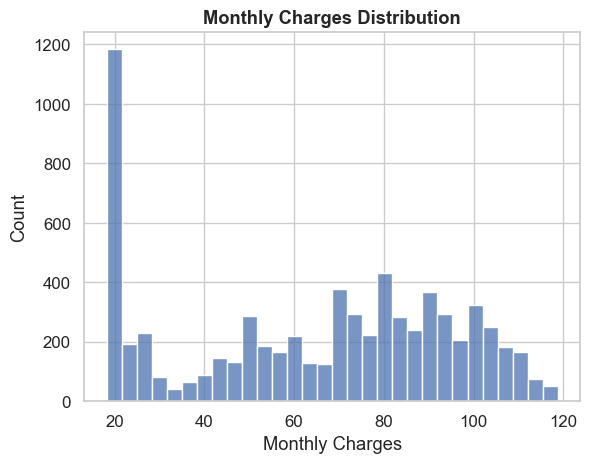

In [22]:
sns.histplot(
    data=df,
    x="Monthly Charges",
    bins=30,
    fill=True,
    palette=colors
    
)

plt.title("Monthly Charges Distribution", fontweight="bold")

plt.show()

Customers with higher monthly charges tend to have increased churn risk, indicating price sensitivity.

**Monthly Charges vs Churn**

C:\Users\jinit\AppData\Local\Temp\ipykernel_1444\52482358.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


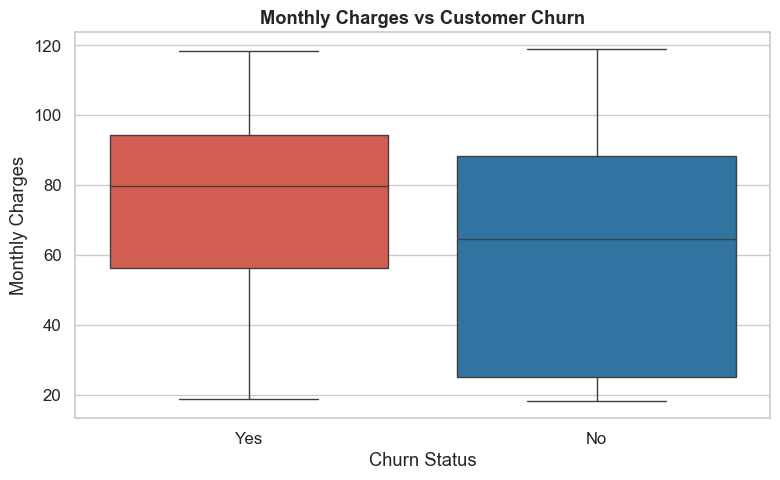

In [23]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    x="Churn Label",
    y="Monthly Charges",
    data=df,
    palette=colors
)

plt.title("Monthly Charges vs Customer Churn", fontweight="bold")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.tight_layout()

plt.show()

**Tenure vs Churn**

C:\Users\jinit\AppData\Local\Temp\ipykernel_1444\3621909252.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


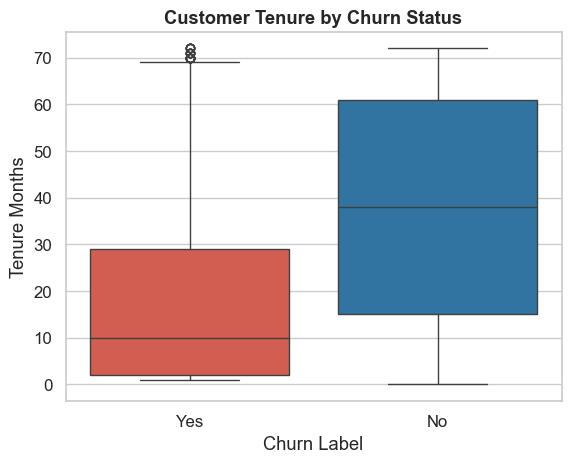

In [24]:
sns.boxplot(
    x="Churn Label",
    y="Tenure Months",
    data=df,
    palette=colors,
)

plt.title("Customer Tenure by Churn Status", fontweight="bold")

plt.show()

Customers with shorter tenure are more likely to churn, highlighting the importance of early customer engagement.

**Top 10 Churn Reasons**

C:\Users\jinit\AppData\Local\Temp\ipykernel_19856\1773427408.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


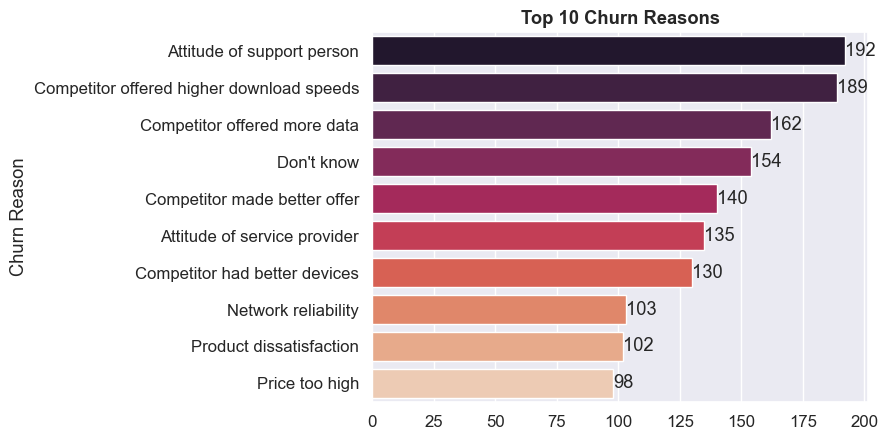

In [68]:
top_reasons = df["Churn Reason"].value_counts().head(10)

ax = sns.barplot(
    x=top_reasons.values,
    y=top_reasons.index,
    palette="rocket",
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Churn Reasons", fontweight="bold")

plt.show()

The most common churn reasons include high service cost, poor customer support, and better competitor offers.

**Churn by Senior Citizen**

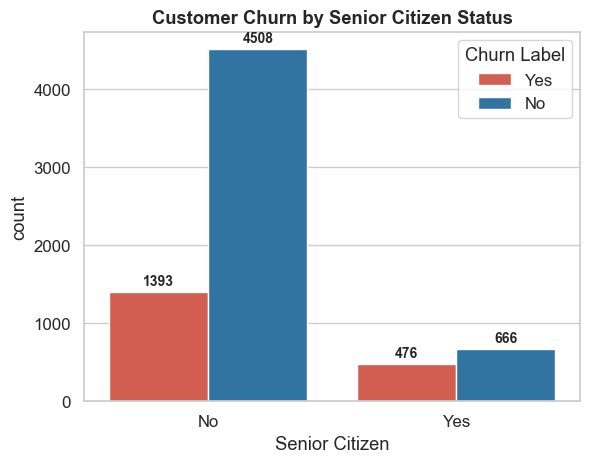

In [25]:
ax = sns.countplot(
    x="Senior Citizen",
    hue="Churn Label",
    data=df,
    palette=colors
)

add_labels(ax)

plt.title("Customer Churn by Senior Citizen Status", fontweight="bold")

plt.show()

Senior citizens show slightly higher churn rates, indicating a potentially vulnerable customer segment.

# Correlation Heatmap of Customer Features

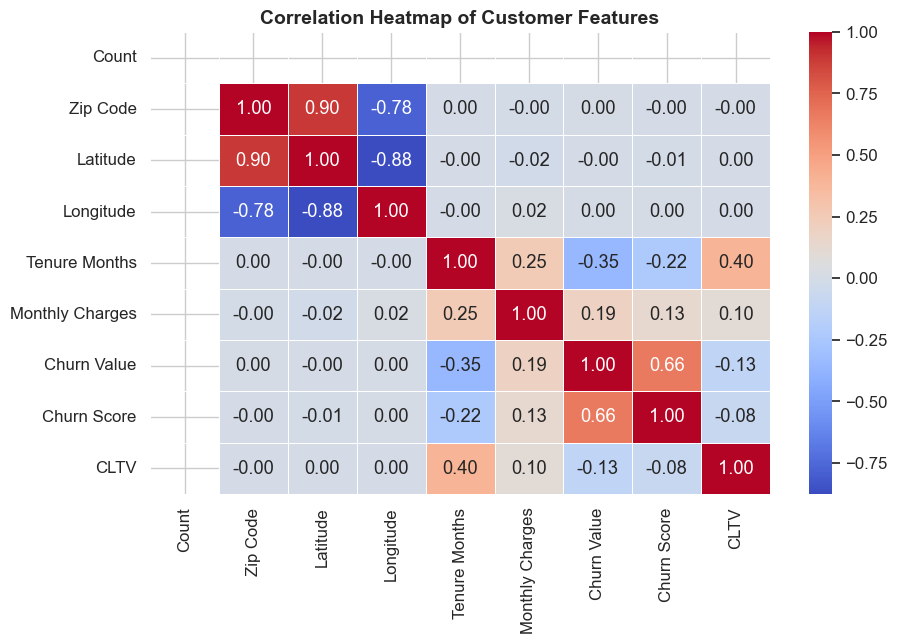

In [26]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Create correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Customer Features",
          fontsize=14,
          fontweight="bold")

plt.show()

The correlation heatmap shows a strong positive relationship between tenure and total charges, indicating that long-term customers contribute more revenue. Monthly charges also demonstrate a moderate correlation with total charges, highlighting the impact of pricing on customer value.